In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qclab import Simulation # import simulation class 
from qclab.models import SpinBoson, DiagonalSpinBoson # import model class 
from qclab.algorithms import MeanField, DecoupledMeanField # import algorithm class 
from qclab.dynamics import serial_driver # import dynamics driver

-0.7853981633974483
[ 0.92387953+0.j -0.38268343+0.j]


100%|██████████| 3001/3001 [00:02<00:00, 1330.60it/s]


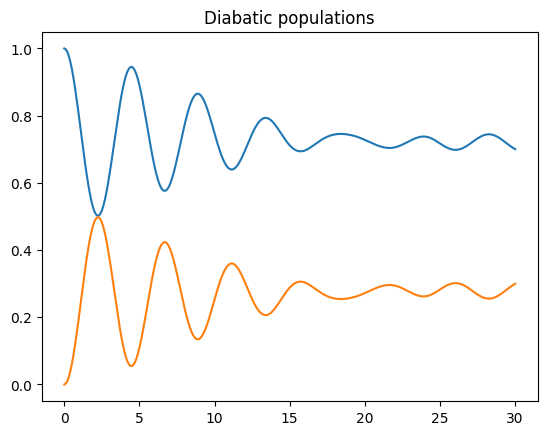

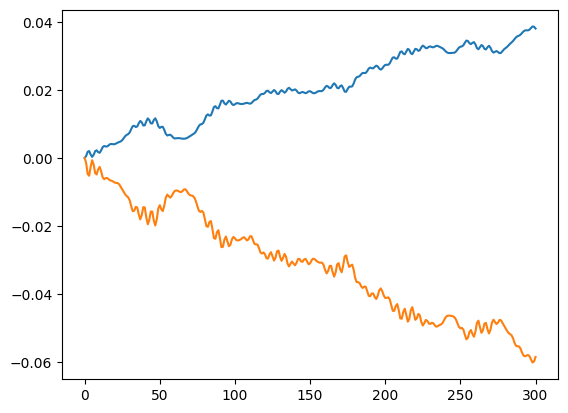

In [2]:
sim = Simulation()

sim.settings.num_trajs = 200
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = DiagonalSpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
# sim.algorithm = MeanField()
sim.algorithm = DecoupledMeanField()

# This is the wavefunction for the original (not diagonal) spin-boson model

wf_db_orig = np.array([1,0], dtype=complex)

theta = np.arctan2(-sim.model.constants.V, sim.model.constants.E)
print(theta)
evecs = np.zeros((2,2),dtype=complex)
evecs[0,0] = np.cos(theta/2)
evecs[0,1] = np.sin(theta/2)
evecs[1,0] = -np.sin(theta/2)
evecs[1,1] = np.cos(theta/2)
wf_db = np.einsum('ij,i->j',np.conj(evecs),wf_db_orig,optimize='greedy')
print(wf_db)
sim.initial_state["wf_db"]= wf_db#np.array([1,0], dtype=complex)

data = serial_driver(sim)


t = data.data_dict['t']
dm_db = data.data_dict['dm_db']
dm_db_orig = np.einsum('ai,tij,bj->tab',evecs,dm_db,np.conj(evecs),optimize='greedy')
plt.plot(t, np.real(np.einsum('tii->ti',dm_db_orig)))
plt.title('Diabatic populations')
plt.show()

ec=data.data_dict['classical_energy']
eq=data.data_dict['quantum_energy']
plt.plot(ec-ec[0])
plt.plot(eq-eq[0])

100%|██████████| 3001/3001 [00:01<00:00, 2125.41it/s]


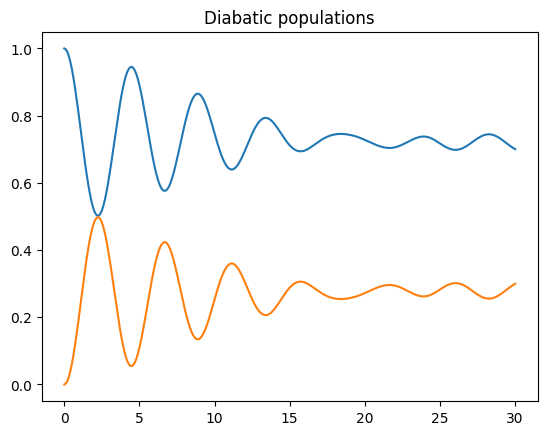

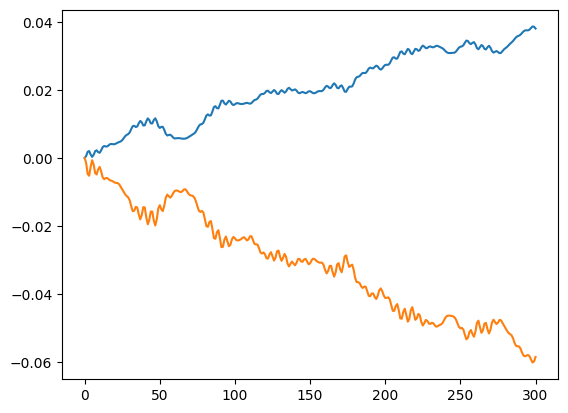

In [5]:
sim = Simulation()

sim.settings.num_trajs = 200
sim.settings.batch_size = 50
sim.settings.tmax = 30
sim.settings.dt_update = 0.01

sim.model = SpinBoson({
    'V':0.5,
    'E':0.5,
    'A':100,
    'W':0.1,
    'l_reorg':0.005,
    'boson_mass':1.0,
    'kBT':1.0,
})
# sim.algorithm = MeanField()
sim.algorithm = DecoupledMeanField()


sim.initial_state["wf_db"]= wf_db_orig

data = serial_driver(sim)

t = data.data_dict['t']
dm_db = data.data_dict['dm_db']
plt.plot(t, np.real(np.einsum('tii->ti',data.data_dict['dm_db'])))
plt.title('Diabatic populations')
plt.show()
ec=data.data_dict['classical_energy']
eq=data.data_dict['quantum_energy']
plt.plot(ec-ec[0])
plt.plot(eq-eq[0])
plt.show()